In [1]:
# Install required packages
!pip install ase
!pip install nglview==3.0.6
!pip install pymatgen
!pip install shap

存取被拒。
存取被拒。
存取被拒。
存取被拒。


# Interpretable Machine Learning for Catalysis: The TinNet Framework

## 1. Importance of Interpretability in Catalysis
In catalysis research, machine learning (ML) models are increasingly used to predict catalytic properties and screen new materials. However, traditional "black-box" ML models often lack **interpretability**, providing limited insight into *why* a prediction is made. Interpretable ML, on the other hand, seeks to combine strong predictive power with scientific transparency. This is crucial for catalyst design, where understanding the underlying chemistry helps researchers improve and trust their models.

## 2. Overview of the TinNet Framework
**TinNet (Theory-infused Neural Network)** integrates well-established catalytic theory directly into a machine learning model, as detailed by Wang *et al.* (2021):  
[Wang, S.-H.; Pillai, H. S.; Wang, S.; Achenie, L. E. K.; Xin, H. *Nat. Commun.* **2021**, 12 (1), 5288.](https://doi.org/10.1038/s41467-021-25639-8)

### Key idea:
- Combine data-driven learning with domain-specific models (e.g., **d-band theory**).
- Achieve **high accuracy** without sacrificing interpretability.
- Explain predictions via physically meaningful parameters (e.g., d-band center).

TinNet has been shown to predict catalytic reactivity (e.g., adsorption energies) **in a way that is consistent with fundamental chemical/physical principles**.

## 3. Domain-Theory Models in TinNet
TinNet includes the following classic theoretical models:

- **Newns–Anderson Model** for *adsorption energies*  
  Explains how the adsorbate's electronic states interact with the metal's d-band.
- **Cohesion Model** for *cohesive energies*  
  Accounts for how strongly metal atoms bond together in the bulk (crucial for stability).
- **Rectangular Band Model** for the *d-band center*  
  A simplified way to incorporate d-band characteristics (center, width, etc.).
- **Moment Theorem** for higher *d-band moments*  
  Extends beyond the band center to capture band width, skewness, and other shape details.

By building these models into the neural network, TinNet predictions can be interpreted in terms of **familiar chemical concepts** (band center shifts, state splitting, etc.).

## 4. Relevance of These Properties for Catalysis
- **Adsorption Energy**: A key descriptor for catalytic activity; too strong or too weak binding of reactants can lower overall activity.
- **Cohesive Energy**: Reflects the stability of the metal catalyst; balancing stability vs. reactivity is often essential.
- **d-band Center**: A widely used electronic descriptor that correlates with the strength of adsorbate-metal interactions.
- **d-band Moments**: Higher moments like the bandwidth or skewness also influence catalytic performance, especially for complex alloys.

Each of these properties ties directly to how a catalyst behaves in real reactions. By interpreting TinNet predictions in these terms, researchers gain direct insight into the driving forces behind catalytic performance.

## 5. Diagram of the TinNet Framework
Below is an example schematic illustrating how theory is infused into TinNet, showing the four theoretical models and their connection to catalytic properties. To embed your own figure (e.g., PNG) in Jupyter, refer to the instructions in the next section.

*(Example placeholder figure; replace or update the path to your own image.)*

```
![TinNet Schematic](TinNet_Schematic.png)
```


## 6. Embedding Figures in a Jupyter Notebook
### A. Using local files
1. Make sure the image file (e.g., `diagram.png`) is in the same folder as your notebook.
2. In a Markdown cell, you can embed it:
   ```
   ![Alt text](diagram.png)
   ```
3. Or in a code cell, using IPython:
   ```python
   from IPython.display import Image, display
   display(Image('diagram.png'))
   ```

### B. From Google Drive
1. **Mount** your Drive (in Google Colab, for instance):
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   ```
2. Use the path to your image file in a similar way (`display(Image(...))`).
3. Alternatively, create a **shareable link** for the image, convert it to a direct link (using `uc?export=view&id=...`), and embed it in Markdown:
   ```
   ![Alt text](https://drive.google.com/uc?export=view&id=FILE_ID)
   ```

### C. Good Practices
- Check image paths carefully; if the notebook and image are in different folders, use a relative path.
- Make sure the image is publicly accessible or shared with appropriate permissions if using an online link.
- For slides and workshops, consider resizing images for clarity. Markdown syntax allows specifying width or height, for example:
  ```
  <img src="diagram.png" width="400"/>
  ```


## Next Steps
In the upcoming sections of this workshop notebook, you can:
1. **Add Python code** demonstrating how to build or apply TinNet models.
2. **Show example datasets** for adsorbate–metal systems.
3. **Visualize predictions** for adsorption energies and interpret them in terms of d-band theory.
4. **Discuss limitations** and future developments (e.g., extension to more complex reaction pathways).

Feel free to expand this notebook with code cells, interactive plots, or advanced analyses that illustrate how TinNet can be integrated into your catalysis workflow!

In [2]:
#!/usr/bin/env python
# This script is adapted from Xie's and Ulissi's scripts.
# Load models

import numpy as np
import os.path
import pickle

from ase import io
from ase.build.surface import *
from ase.visualize import view

In [3]:
# Load images from traj file
images = io.read('./data/clean_images.traj', index=slice(None))

In [4]:
# Create your own images
with open('./data/MaterialDict.pkl', 'rb') as f:
    data = pickle.load(f, encoding='bytes')
data = {k.decode('utf8'): v for k, v in data.items()}

pure_cu = fcc111('Cu', size=(2,2,4), a=data['Cu'][b'qLattConst-PBE'])
pure_cu.center(vacuum=7.5, axis=2)

cu_ag_saa = fcc111('Ag', size=(2,2,4), a=data['Ag'][b'qLattConst-PBE'])
cu_ag_saa.center(vacuum=7.5, axis=2)
cu_ag_saa[-1].symbol ='Cu'

cu_ag_core_shell = fcc111('Ag', size=(2,2,4), a=data['Ag'][b'qLattConst-PBE'])
cu_ag_core_shell.center(vacuum=7.5, axis=2)
for i in range(0,4):
    cu_ag_core_shell[-1-i].symbol ='Cu'

cu_ag_sandwich = fcc111('Ag', size=(2,2,4), a=data['Ag'][b'qLattConst-PBE'])
cu_ag_sandwich.center(vacuum=7.5, axis=2)
for i in range(4,8):
    cu_ag_sandwich[-1-i].symbol ='Cu'

cu_dimer_ag = fcc111('Ag', size=(4,4,4), a=data['Ag'][b'qLattConst-PBE'])
cu_dimer_ag.center(vacuum=7.5, axis=2)
cu_dimer_ag[-1].symbol ='Cu'
cu_dimer_ag[-2].symbol ='Cu'

cu_di_saa_ag = fcc111('Ag', size=(4,4,4), a=data['Ag'][b'qLattConst-PBE'])
cu_di_saa_ag.center(vacuum=7.5, axis=2)
cu_di_saa_ag[-1].symbol ='Cu'
cu_di_saa_ag[-3].symbol ='Cu'


In [5]:
images = io.read('./data/OH_images.traj', index=slice(None))

pure_pt = images[0]
Pt_MLPt3Co111 = images[1]

o_h_indices = [i for i, atom in enumerate(pure_pt) if atom.symbol == 'O' or atom.symbol == 'H']
for i in sorted(o_h_indices, reverse=True):
    del pure_pt[i]

o_h_indices = [i for i, atom in enumerate(Pt_MLPt3Co111) if atom.symbol == 'O' or atom.symbol == 'H']
for i in sorted(o_h_indices, reverse=True):
    del Pt_MLPt3Co111[i]

# Model 1: adsorption energy
## OH on the atop site

In [6]:
# Import pretrained model
from tinnet import tinnet
model = tinnet.AdsorptionEnergy(image=Pt_MLPt3Co111, site_inx=[20], adsorbate='OH', name='Pt_MLPt3Co111')

In [7]:
model.predict()

The adsorption energy of OH on the atop site (index [20]) of Pt_MLPt3Co111: -1.85 ± 0.04 eV


array([-1.777572 , -1.9051715, -1.7933737, -1.8393646, -1.9174023,
       -1.8434682, -1.878548 , -1.835736 , -1.881953 , -1.8110243],
      dtype=float32)

(<Figure size 675x337.5 with 1 Axes>, <Axes: xlabel='$E_{ad}^{OH, top}$ (eV)'>)

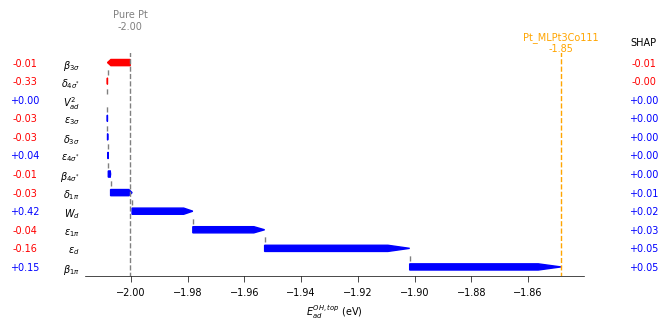

In [8]:
model.explain_shap(ref_image=pure_pt,
                   ref_site_inx=[5],
                   ref_name='Pure Pt',
                   save_fig='png')

## O on the atop site

In [9]:
# Import pretrained model
from tinnet import tinnet
model = tinnet.AdsorptionEnergy(image=cu_ag_saa, site_inx=[15], adsorbate='O', name='Cu1Ag SAA')

In [10]:
model.predict()

The adsorption energy of O on the atop site (index [15]) of Cu1Ag SAA: -3.24 ± 0.04 eV


array([-3.3409116, -3.2596357, -3.213527 , -3.226655 , -3.2586572,
       -3.2221158, -3.2274983, -3.2225552, -3.239396 , -3.2382877],
      dtype=float32)

(<Figure size 675x337.5 with 1 Axes>, <Axes: xlabel='$E_{ad}^{O, top}$ (eV)'>)

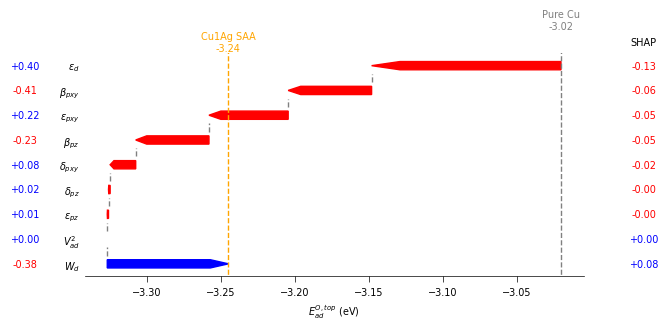

In [11]:
model.explain_shap(ref_image=pure_cu,
                   ref_site_inx=[15],
                   ref_name='Pure Cu',
                   save_fig='png')

# Model 2: band center

In [12]:
# Import pretrained model
from tinnet import tinnet
model = tinnet.BandCenter(image=cu_ag_saa, atom_inx=15, name='Cu1Ag SAA')

In [13]:
model.predict()

band center of the atom (index 15) of Cu1Ag SAA: -1.97 ± 0.02 eV


array([-1.9689293, -1.9560248, -1.9717814, -2.001378 , -1.9644446,
       -1.9719968, -1.9871368, -1.9429631, -1.9645268, -1.9804612],
      dtype=float32)

(<Figure size 675x337.5 with 1 Axes>,
 <Axes: xlabel='$d\\rm{-band\\ center}$ (eV)'>)

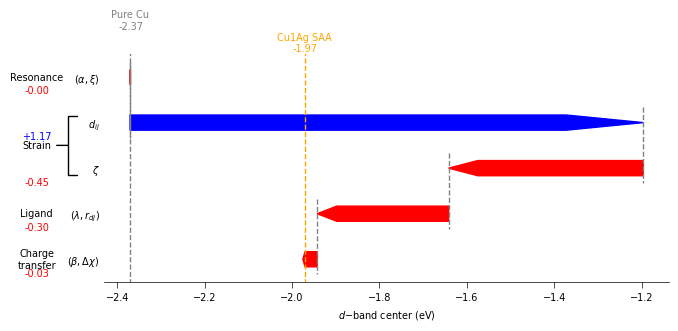

In [14]:
model.explain_shap(ref_image=pure_cu,
                   ref_atom_inx=15,
                   ref_name='Pure Cu',
                   save_fig='png')

# DFT calculated d-band center,
# Pure Cu: -2.3687 eV
# Cu1Ag SAA: -1.9636 eV

# Model 3: band moments

In [15]:
# Import pretrained model
from tinnet import tinnet
model = tinnet.BandMoments(image=cu_ag_saa, atom_inx=15, name='Cu1Ag SAA')

In [16]:
model.predict()

--- Moments for atom index 15 of Cu1Ag SAA ---
Second Moment  (⟨ε²⟩): 0.85 ± 0.03  → related to band width / energy spread
Third Moment   (⟨ε³⟩): 0.56 ± 0.03  → indicates asymmetry / skewness of DOS
Fourth Moment  (⟨ε⁴⟩): 11.98 ± 0.59  → measures kurtosis / 'tailedness' of DOS


array([[ 0.83056127,  0.53207161, 11.53975674],
       [ 0.82783381,  0.60514959, 11.66322469],
       [ 0.81554947,  0.55534911, 11.32310021],
       [ 0.88138692,  0.61137827, 12.83253504],
       [ 0.87858908,  0.59461824, 12.53343248],
       [ 0.87992915,  0.53298178, 12.84509391],
       [ 0.87077924,  0.55143155, 12.29038071],
       [ 0.84359626,  0.51074905, 12.03648232],
       [ 0.8141485 ,  0.5848638 , 11.15638692],
       [ 0.83596304,  0.53839549, 11.57115655]])

# Model 4: cohesive energy

In [17]:
# Import pretrained model
from tinnet import tinnet
model = tinnet.CohesiveEnergy(image=cu_dimer_ag, name='Cu_dimer_Ag')

In [18]:
model.predict()

Cohesive Energy
Material        Cohesive Energy (eV/atom)
---------------------------------------------
Cu_dimer_Ag                    -5.65 ± 0.02                


array([-5.655207 , -5.6683903, -5.64144  , -5.6608   , -5.655453 ,
       -5.626161 , -5.640581 , -5.642462 , -5.6759095, -5.6188364],
      dtype=float32)

(<Figure size 675x337.5 with 1 Axes>,
 <Axes: xlabel='$E_{Cohesive}$ (eV/atom)'>)

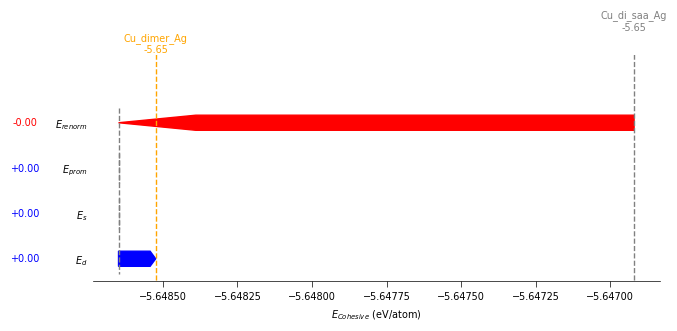

In [19]:
model.explain_shap(ref_image=cu_di_saa_ag,
                   ref_name='Cu_di_saa_Ag',
                   save_fig='png')